In [8]:
# 1. 导入所有库
import time
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from joblib import Parallel, delayed

np.random.seed(42) 

In [9]:
# 2. 设置随机种子 + 数据集准备
from sklearn.model_selection import train_test_split

print("Loading official PennyLane 'Bars and Stripes' Benchmark Dataset...")
dataset = qml.data.load("other", name="bars-and-stripes")[0]

# 1. 提取官方的全部数据
X_train_official = dataset.train['4']['inputs']
Y_train_official = dataset.train['4']['labels']
X_test_official = dataset.test['4']['inputs']
Y_test_official = dataset.test['4']['labels']

# 2. 将训练集和测试集合并，得到 1200 个总样本
X_combined = np.concatenate([X_train_official, X_test_official], axis=0)
Y_combined = np.concatenate([Y_train_official, Y_test_official], axis=0)

# 统一标签处理为 0 和 1
Y_combined = np.where(np.array(Y_combined) <= 0, 0, 1).ravel()

# 3. 从中随机抽取 800 个总样本
idx = np.random.choice(len(X_combined), 800, replace=False)
X_subset = X_combined[idx]
Y_subset = Y_combined[idx]

# 4. 按照 0.2 的比例划分测试集 (800 * 0.8 = 640 训练集, 800 * 0.2 = 160 测试集)
X_train_full, X_test_full, Y_train, Y_test = train_test_split(
    X_subset, Y_subset, test_size=0.2, random_state=42
)

print(f"Custom Dataset Loaded: Train={len(X_train_full)}, Test={len(X_test_full)}")

# ==================== PCA 降维 ====================
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=42)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca  = pca.transform(X_test_full)

# 归一化到 [0, π]
minmax = MinMaxScaler(feature_range=(0, np.pi))
X_train = minmax.fit_transform(X_train_pca)
X_test  = minmax.transform(X_test_pca)
X_test  = np.clip(X_test, 0, np.pi)

print(f"Dataset dimensionality reduced to {n_qubits} for {n_qubits}-qubit simulation.")
print(f"Final shapes -> Train: {X_train.shape}, Test: {X_test.shape}")

Loading official PennyLane 'Bars and Stripes' Benchmark Dataset...
Custom Dataset Loaded: Train=640, Test=160
Dataset dimensionality reduced to 4 for 4-qubit simulation.
Final shapes -> Train: (640, 4), Test: (160, 4)


In [10]:
# 3. QSVM 电路定义
n_qubits = 4
device = qml.device('lightning.qubit', wires=n_qubits)

@qml.qnode(device)
def get_quantum_state(x):
    """标准 ZZFeatureMap (reps=2)，全局纠缠"""
    for _ in range(2):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)
        for i in range(n_qubits - 1):
            for j in range(i + 1, n_qubits):
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                qml.CNOT(wires=[i, j])
    return qml.state()

In [11]:
# 4. 模型定义
class FastQSVM:
    def __init__(self, n_jobs=-1):
        # n_jobs=-1 自动调用电脑所有 CPU 核心
        self.svm = SVC(kernel="precomputed", random_state=42)
        self.n_jobs = n_jobs
        self.train_states = None 
        
    def _compute_states(self, X):
        """多核并行提取量子态"""
        states = Parallel(n_jobs=self.n_jobs)(delayed(get_quantum_state)(x) for x in X)
        return np.array(states)

    def fit(self, X, y):
        self.train_states = self._compute_states(X)
        K_train = np.abs(self.train_states.conj().dot(self.train_states.T)) ** 2
        self.svm.fit(K_train, y)
        return self

    def predict(self, X):
        X_states = self._compute_states(X)
        K_test = np.abs(X_states.conj().dot(self.train_states.T)) ** 2
        return self.svm.predict(K_test)
        
    def decision_function(self, X):
        X_states = self._compute_states(X)
        K_test = np.abs(X_states.conj().dot(self.train_states.T)) ** 2
        return self.svm.decision_function(K_test)

class ClassicSVM:
    def __init__(self):
        self.model = SVC(kernel="rbf", random_state=42)
        
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
        
    def predict(self, X):
        return self.model.predict(X)
        
    def decision_function(self, X):
        return self.model.decision_function(X)

In [12]:
# 5. 训练与耗时统计
print("=== 训练 QSVM (多核加速版) ===")
qsvm_model = FastQSVM(n_jobs=-1) 
start = time.time()
qsvm_model.fit(X_train, Y_train)
qsvm_time = time.time() - start
print(f"QSVM 训练耗时: {qsvm_time:.2f}秒")

print("\n=== 训练 经典 SVM ===")
svm_model = ClassicSVM()
start = time.time()
svm_model.fit(X_train, Y_train)
svm_time = time.time() - start
print(f"经典 SVM 训练耗时: {svm_time:.2f}秒")

=== 训练 QSVM (多核加速版) ===
QSVM 训练耗时: 10.33秒

=== 训练 经典 SVM ===
经典 SVM 训练耗时: 0.01秒


In [13]:
#6.评估函数 + 打印结果
# ==================== 测试集评估 ====================
def evaluate(model, X_t, y_t):
    preds = model.predict(X_t)
    probs = model.decision_function(X_t)
    
    acc = accuracy_score(y_t, preds)
    prec = precision_score(y_t, preds, zero_division=0)
    rec = recall_score(y_t, preds, zero_division=0)
    f1 = f1_score(y_t, preds, zero_division=0)
    auc = roc_auc_score(y_t, probs)
    return acc, prec, rec, f1, auc, probs, preds

qsvm_acc, qsvm_prec, qsvm_rec, qsvm_f1, qsvm_auc, qsvm_probs, qsvm_preds = evaluate(qsvm_model, X_test, Y_test)
svm_acc, svm_prec, svm_rec, svm_f1, svm_auc, svm_probs, svm_preds = evaluate(svm_model, X_test, Y_test)

print("\n=== 结果对比 ===")
print(f"QSVM - Acc: {qsvm_acc:.4f} | Prec: {qsvm_prec:.4f} | Rec: {qsvm_rec:.4f} | F1: {qsvm_f1:.4f} | AUC: {qsvm_auc:.4f}")
print(f"SVM  - Acc: {svm_acc:.4f} | Prec: {svm_prec:.4f} | Rec: {svm_rec:.4f} | F1: {svm_f1:.4f} | AUC: {svm_auc:.4f}")


=== 结果对比 ===
QSVM - Acc: 0.8250 | Prec: 0.8060 | Rec: 0.7826 | F1: 0.7941 | AUC: 0.9059
SVM  - Acc: 0.9250 | Prec: 0.8904 | Rec: 0.9420 | F1: 0.9155 | AUC: 0.9861


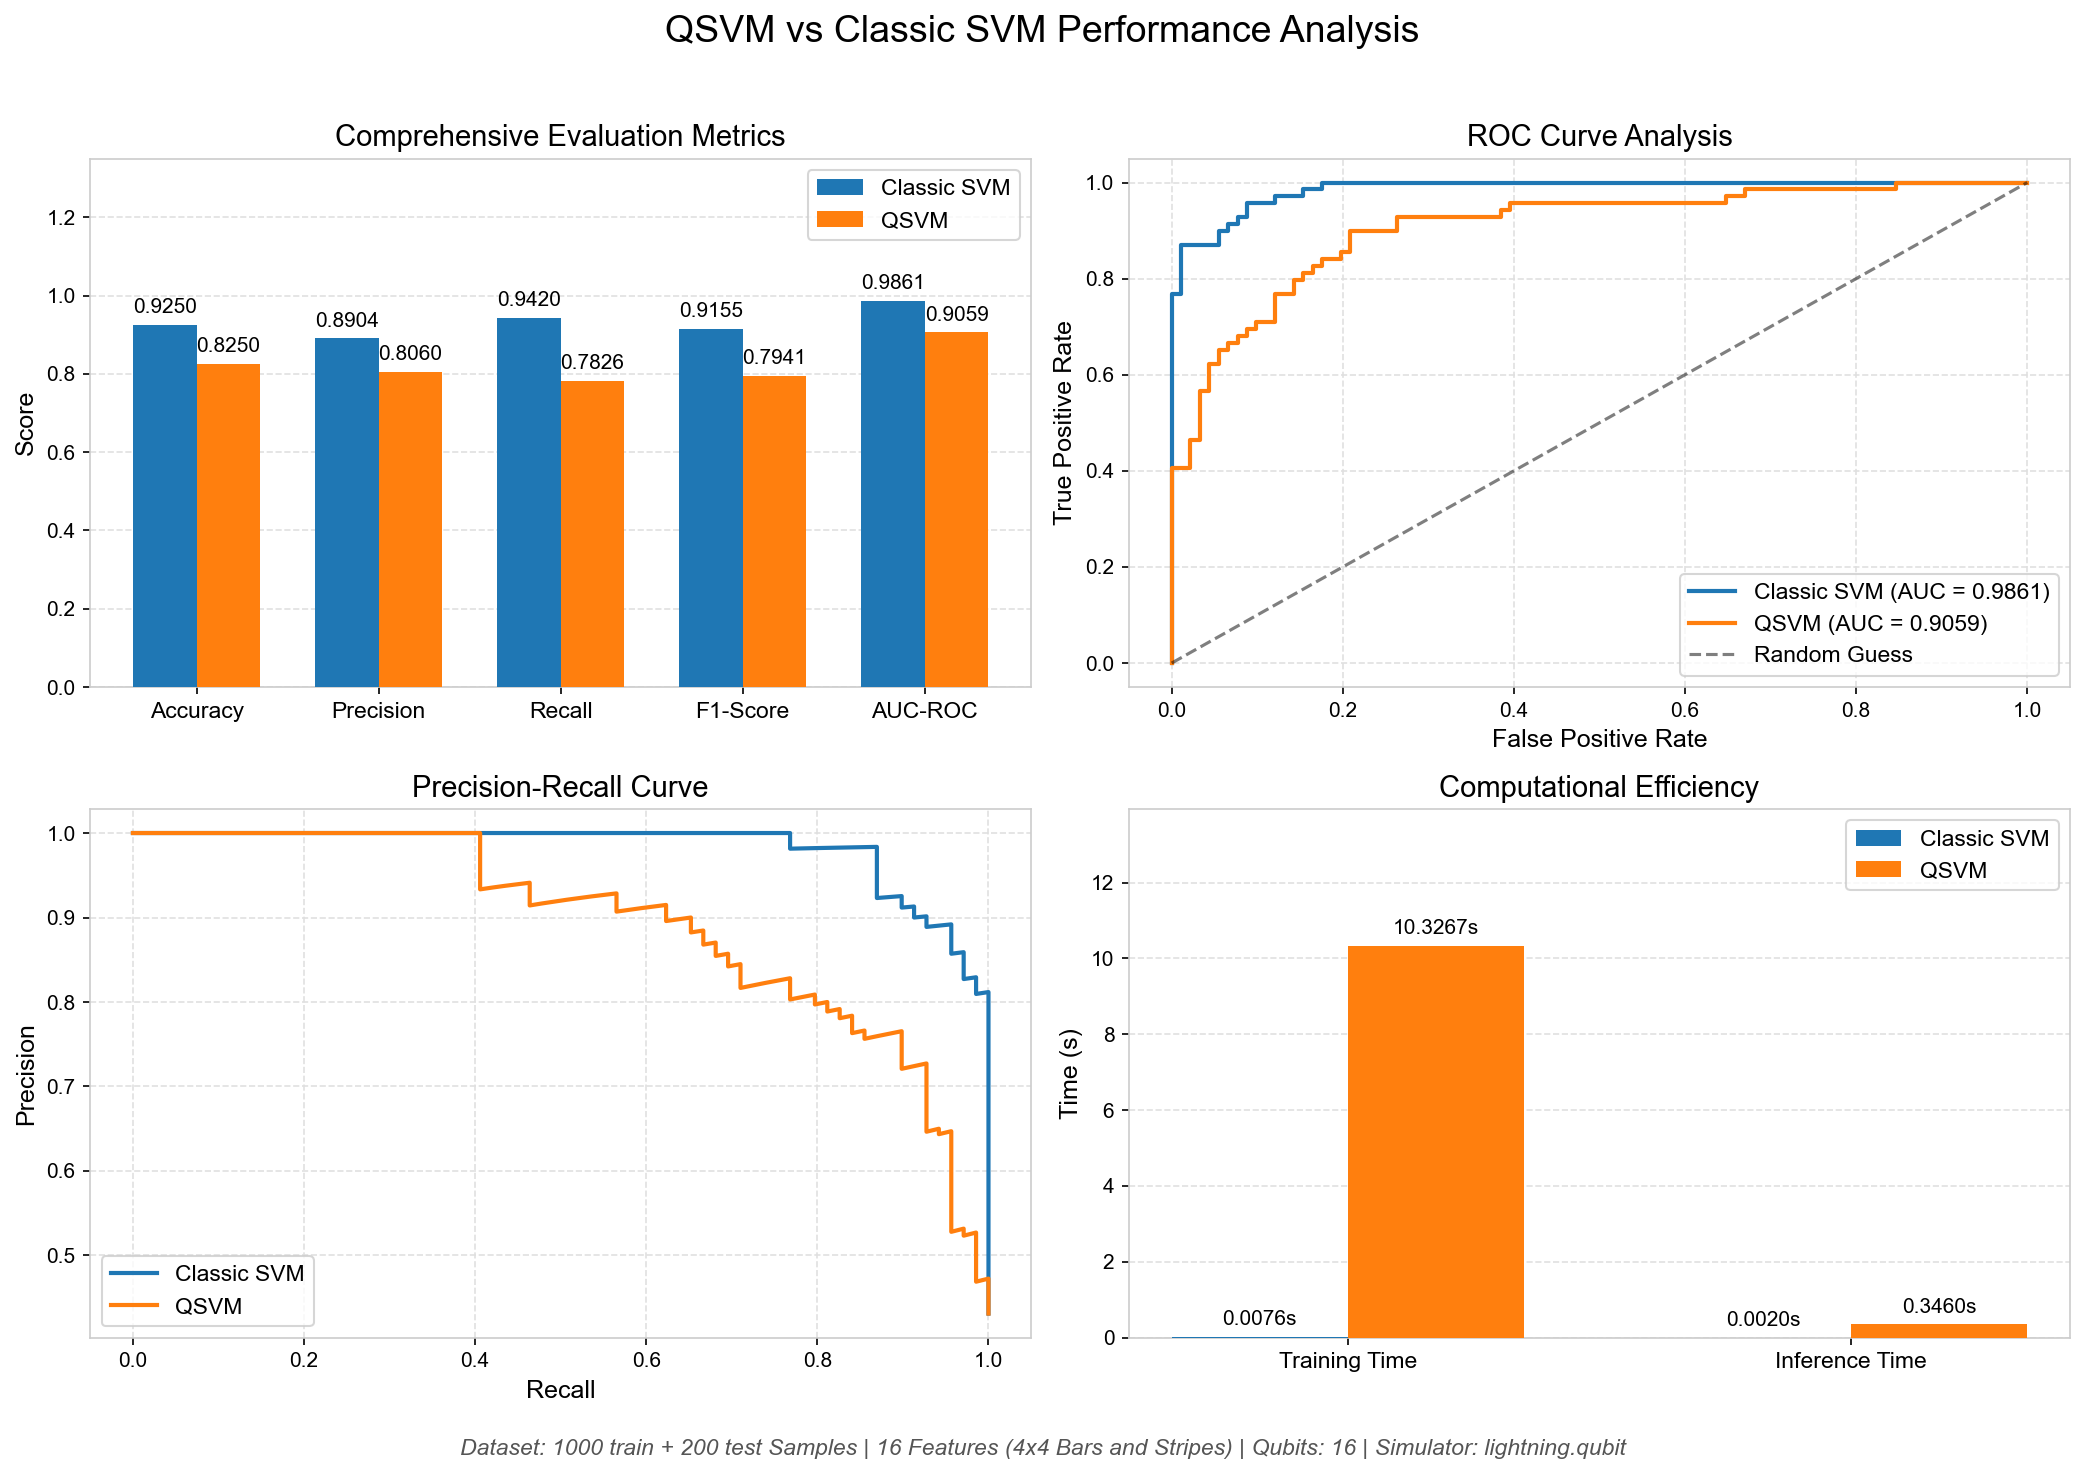

In [14]:
# ==================== 第7块：合并主图 + 附图（2x2布局，浅色清爽样式，图例右上防遮挡） ====================
from sklearn.metrics import roc_curve, precision_recall_curve

# --- 提取自代码第4块的绘图配置，减轻视觉深重感 ---
plt.rcParams.update({
    'font.sans-serif': ['Arial'], 
    'axes.edgecolor': '#cccccc',   # 浅灰色坐标轴边框
    'grid.color': '#e0e0e0',       # 浅灰色网格线
    'grid.linestyle': '--'         # 虚线网格
})

# 计算推理时间 (QSVM & SVM 适用纯粹的 predict 计算)
def get_inference_time(model, data):
    start = time.time()
    _ = model.predict(data)
    return time.time() - start

qsvm_inf_time = get_inference_time(qsvm_model, X_test)
svm_inf_time = get_inference_time(svm_model, X_test)

# 颜色方案
classical_color = '#1f77b4'   # 经典 SVM（蓝色）
quantum_color   = '#ff7f0e'   # 量子 QSVM（橙色）

# 创建画布
fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
fig.suptitle('QSVM vs Classic SVM Performance Analysis', fontsize=18, y=0.98)

# ==================== Top-Left: Comprehensive Evaluation Metrics ====================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1, svm_auc]
qsvm_vals = [qsvm_acc, qsvm_prec, qsvm_rec, qsvm_f1, qsvm_auc]

x = np.arange(len(metrics))
width = 0.35

for i in range(len(metrics)):
    axs[0,0].bar(x[i] - width/2, svm_vals[i], width, color=classical_color, 
                 label='Classic SVM' if i==0 else "", zorder=3)
    axs[0,0].bar(x[i] + width/2, qsvm_vals[i], width, color=quantum_color, 
                 label='QSVM' if i==0 else "", zorder=3)
    
    axs[0,0].text(x[i] - width/2, svm_vals[i] + 0.02, f'{svm_vals[i]:.4f}', 
                  ha='center', va='bottom', fontsize=10)
    axs[0,0].text(x[i] + width/2, qsvm_vals[i] + 0.02, f'{qsvm_vals[i]:.4f}', 
                  ha='center', va='bottom', fontsize=10)

axs[0,0].set_ylabel('Score', fontsize=12)
axs[0,0].set_title('Comprehensive Evaluation Metrics', fontsize=14)
axs[0,0].set_xticks(x)
axs[0,0].set_xticklabels(metrics, fontsize=11)
# 调高Y轴上限到1.35，给右上角图例留出完美空隙
axs[0,0].set_ylim(0, 1.35) 
axs[0,0].legend(fontsize=11, loc='upper right')
axs[0,0].grid(axis='y', zorder=0)

# ==================== Top-Right: ROC Curve Analysis ====================
fpr_s, tpr_s, _ = roc_curve(Y_test, svm_probs)
fpr_q, tpr_q, _ = roc_curve(Y_test, qsvm_probs)

axs[0,1].plot(fpr_s, tpr_s, label=f'Classic SVM (AUC = {svm_auc:.4f})', color=classical_color, lw=2)
axs[0,1].plot(fpr_q, tpr_q, label=f'QSVM (AUC = {qsvm_auc:.4f})', color=quantum_color, lw=2)
axs[0,1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Guess')
axs[0,1].set_xlabel('False Positive Rate', fontsize=12)
axs[0,1].set_ylabel('True Positive Rate', fontsize=12)
axs[0,1].set_title('ROC Curve Analysis', fontsize=14)
# ROC曲线会延伸到右上角，所以图例固定在右下角防遮挡
axs[0,1].legend(fontsize=11, loc='lower right') 
axs[0,1].grid(True)

# ==================== Bottom-Left: Precision-Recall Curve (替换学习曲线) ====================
# 因为SVM没有Epoch级别的Loss，所以这里替换为PR曲线来评估类别不平衡情况下的表现
prec_s, rec_s, _ = precision_recall_curve(Y_test, svm_probs)
prec_q, rec_q, _ = precision_recall_curve(Y_test, qsvm_probs)

axs[1,0].plot(rec_s, prec_s, label='Classic SVM', color=classical_color, lw=2)
axs[1,0].plot(rec_q, prec_q, label='QSVM', color=quantum_color, lw=2)
axs[1,0].set_title('Precision-Recall Curve', fontsize=14)
axs[1,0].set_xlabel('Recall', fontsize=12)
axs[1,0].set_ylabel('Precision', fontsize=12)
# PR曲线通常在右上角密集，所以图例放左下角
axs[1,0].legend(fontsize=11, loc='lower left')
axs[1,0].grid(True)

# ==================== Bottom-Right: Computational Efficiency ====================
eff_labels = ['Training Time', 'Inference Time']
svm_eff = [svm_time, svm_inf_time]
qsvm_eff = [qsvm_time, qsvm_inf_time]
x_eff = np.arange(len(eff_labels))

axs[1,1].bar(x_eff - width/2, svm_eff, width, color=classical_color, label='Classic SVM', zorder=3)
axs[1,1].bar(x_eff + width/2, qsvm_eff, width, color=quantum_color, label='QSVM', zorder=3)

axs[1,1].set_xticks(x_eff)
axs[1,1].set_xticklabels(eff_labels, fontsize=11)
axs[1,1].set_ylabel('Time (s)', fontsize=12)
axs[1,1].set_title('Computational Efficiency', fontsize=14)

max_time = max(max(svm_eff), max(qsvm_eff))
# 动态调高Y轴上限到 1.35倍，留出空间放图例
axs[1,1].set_ylim(0, max_time * 1.35)
axs[1,1].legend(fontsize=11, loc='upper right')

offset = max_time * 0.02
for i in range(2):
    axs[1,1].text(x_eff[i] - width/2, svm_eff[i] + offset, f'{svm_eff[i]:.4f}s', 
                  ha='center', va='bottom', fontsize=10)
    axs[1,1].text(x_eff[i] + width/2, qsvm_eff[i] + offset, f'{qsvm_eff[i]:.4f}s', 
                  ha='center', va='bottom', fontsize=10)

axs[1,1].grid(axis='y', zorder=0)

# 底部数据集信息 (根据 QSVM 前面的生成数据进行匹配: 200 samples, 4 features)
plt.figtext(0.5, 0.02, 
            'Dataset: 1000 train + 200 test Samples | 16 Features (4x4 Bars and Stripes) | '
            'Qubits: 16 | Simulator: lightning.qubit', 
            ha='center', fontsize=11, color='#555555', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()